# Task 2 Notebook for Python Web Scraping Assignment
## Caolán Maguire 25256569

In [26]:
# Libraries
import os
from os import listdir
from os.path import isfile, isdir, join
import json
import pandas as pd
from IPython.display import Image
# !pip uninstall numpy
# !pip install "numpy<2.0"

In [27]:
# Load the saved dataset from Task 1
mypath = 'output'
onlydirs = [d for d in listdir(mypath) if isdir(join(mypath, d))]
print(onlydirs)

# Dictionary to store all listings by quarter
quarterly_data = {
    'Q1': [],
    'Q2': [],
    'Q3': [],
    'Q4': []
}

['Q1', 'Q2', 'Q3', 'Q4']


#### Explainer
I run through my directories above and belowload all the listings into an object callled quarterly_data - I've now collected all my data from Task1

In [28]:
# Load all JSON files
for dirs in onlydirs:
    print(' +' + dirs)
    mypath = 'output/'+ dirs
    onlyfiles = [f for f in os.listdir(mypath) if os.path.isfile(os.path.join(mypath, f))]
    
    for file in onlyfiles:
        # Only process JSON files
        if file.endswith('.json'):
            filepath = os.path.join(mypath, file)
            with open(filepath, 'r') as f:
                listing = json.load(f)
                quarterly_data[dirs].append(listing)
    
    print(' - Loaded ' + str(len(quarterly_data[dirs])) + ' listings from ' + dirs)

 +Q1
 - Loaded 1008 listings from Q1
 +Q2
 - Loaded 990 listings from Q2
 +Q3
 - Loaded 910 listings from Q3
 +Q4
 - Loaded 886 listings from Q4


#### Explainer

In [40]:
# Function to extract price as a number
def extract_price(price_str):
    # Remove €, \u20ac (Euro symbol), commas, 'per month', 'EUR', and extra spaces
    cleaned = price_str.replace('€', '').replace('\u20ac', '').replace('EUR', '').replace(',', '').replace('per month', '').strip()
    try:
        return float(cleaned)
    except:
        return None

# Function to extract bedrooms as a number
def extract_bedrooms(bed_str):
    # Extract number from strings like "3 Bedrooms", "2", "1 Bedroom"
    import re
    match = re.search(r'\d+', bed_str)
    if match:
        return int(match.group())
    return None

# Function to extract month from record string
def extract_month(record_str):
    # Extract month from "January 2025 — Apartment" format
    import re
    months = ['January', 'February', 'March', 'April', 'May', 'June', 
              'July', 'August', 'September', 'October', 'November', 'December']
    for month in months:
        if month in record_str:
            return month
    return None

# Calculate average rent per quarter
print('\n' + '='*50)
print('AVERAGE RENT BY QUARTER')
print('='*50)


AVERAGE RENT BY QUARTER


In [30]:
quarter_averages = {}

for quarter in ['Q1', 'Q2', 'Q3', 'Q4']:
    prices = []
    for listing in quarterly_data[quarter]:
        price = extract_price(listing.get('Price', '0'))
        if price:
            prices.append(price)
    
    if len(prices) > 0:
        avg_price = sum(prices) / len(prices)
        quarter_averages[quarter] = avg_price
        print(quarter + ': €' + str(round(avg_price, 2)) + ' (from ' + str(len(prices)) + ' listings)')
    else:
        quarter_averages[quarter] = 0
        print(quarter + ': No data')

# Calculate average rent per month
print('\n' + '='*50)
print('AVERAGE RENT BY MONTH')
print('='*50)

Q1: €2328.79 (from 1008 listings)
Q2: €2480.73 (from 990 listings)
Q3: €2489.14 (from 910 listings)
Q4: €2581.96 (from 886 listings)

AVERAGE RENT BY MONTH


In [31]:
monthly_data = {}

for quarter in ['Q1', 'Q2', 'Q3', 'Q4']:
    for listing in quarterly_data[quarter]:
        month = extract_month(listing.get('record', ''))
        price = extract_price(listing.get('Price', '0'))
        
        if month and price:
            if month not in monthly_data:
                monthly_data[month] = []
            monthly_data[month].append(price)

# Calculate averages and display
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_averages = {}

for month in month_order:
    if month in monthly_data:
        avg_price = sum(monthly_data[month]) / len(monthly_data[month])
        monthly_averages[month] = avg_price
        print(month + ': €' + str(round(avg_price, 2)) + ' (from ' + str(len(monthly_data[month])) + ' listings)')
    else:
        print(month + ': No data')

# Calculate average rent per quarter PER BEDROOM COUNT
print('\n' + '='*50)
print('AVERAGE RENT BY QUARTER AND BEDROOMS')
print('='*50)

# Structure: bedroom_quarterly_data[bedrooms][quarter] = [prices]
bedroom_quarterly_data = {}

for quarter in ['Q1', 'Q2', 'Q3', 'Q4']:
    for listing in quarterly_data[quarter]:
        price = extract_price(listing.get('Price', '0'))
        bedrooms = extract_bedrooms(listing.get('Bedrooms', '0'))
        
        if price and bedrooms:
            if bedrooms not in bedroom_quarterly_data:
                bedroom_quarterly_data[bedrooms] = {'Q1': [], 'Q2': [], 'Q3': [], 'Q4': []}
            bedroom_quarterly_data[bedrooms][quarter].append(price)

January: €2366.72 (from 360 listings)
February: €2336.81 (from 320 listings)
March: €2279.33 (from 328 listings)
April: €2474.13 (from 358 listings)
May: €2445.85 (from 342 listings)
June: €2530.0 (from 290 listings)
July: €2566.82 (from 314 listings)
August: €2288.41 (from 276 listings)
September: €2586.06 (from 320 listings)
October: €2554.16 (from 308 listings)
November: €2597.61 (from 360 listings)
December: €2595.41 (from 218 listings)

AVERAGE RENT BY QUARTER AND BEDROOMS


In [32]:
# Calculate averages
bedroom_quarterly_averages = {}

for bedrooms in sorted(bedroom_quarterly_data.keys()):
    print('\n' + str(bedrooms) + ' Bedroom(s):')
    bedroom_quarterly_averages[bedrooms] = {}
    
    for quarter in ['Q1', 'Q2', 'Q3', 'Q4']:
        prices = bedroom_quarterly_data[bedrooms][quarter]
        if len(prices) > 0:
            avg_price = sum(prices) / len(prices)
            bedroom_quarterly_averages[bedrooms][quarter] = avg_price
            print('  ' + quarter + ': €' + str(round(avg_price, 2)) + ' (from ' + str(len(prices)) + ' listings)')
        else:
            bedroom_quarterly_averages[bedrooms][quarter] = None
            print('  ' + quarter + ': No data')

# Visualize with matplotlib
try:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    
    # Create figure with 3 subplots
    fig = plt.figure(figsize=(18, 6))
    
    # Plot 1: Quarterly averages
    ax1 = plt.subplot(1, 3, 1)
    quarters = list(quarter_averages.keys())
    avg_prices_q = list(quarter_averages.values())
    colors_q = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
    
    ax1.bar(quarters, avg_prices_q, color=colors_q, edgecolor='black', linewidth=1.5)
    ax1.set_xlabel('Quarter', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Average Rent (€)', fontsize=12, fontweight='bold')
    ax1.set_title('Average Rental Price by Quarter - 2025', fontweight='bold', fontsize=14)
    ax1.grid(True, alpha=0.3, axis='y')
    
    for i, v in enumerate(avg_prices_q):
        ax1.text(i, v + 50, '€' + str(int(round(v, 0))), ha='center', fontweight='bold')
    
    # Plot 2: Monthly averages
    ax2 = plt.subplot(1, 3, 2)
    months_with_data = [m for m in month_order if m in monthly_averages]
    avg_prices_m = [monthly_averages[m] for m in months_with_data]
    
    ax2.bar(range(len(months_with_data)), avg_prices_m, color='#9B59B6', edgecolor='black', linewidth=1.5)
    ax2.set_xlabel('Month', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Average Rent (€)', fontsize=12, fontweight='bold')
    ax2.set_title('Average Rental Price by Month - 2025', fontweight='bold', fontsize=14)
    ax2.set_xticks(range(len(months_with_data)))
    ax2.set_xticklabels([m[:3] for m in months_with_data], rotation=45)
    ax2.grid(True, alpha=0.3, axis='y')
    
    for i, v in enumerate(avg_prices_m):
        ax2.text(i, v + 50, '€' + str(int(round(v, 0))), ha='center', fontweight='bold', fontsize=9)
    
    # Plot 3: Line graph by bedrooms across quarters
    ax3 = plt.subplot(1, 3, 3)
    
    # Line colors for different bedroom counts
    line_colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6', '#1ABC9C']
    marker_styles = ['o', 's', '^', 'D', 'v', 'p']
    
    quarters_list = ['Q1', 'Q2', 'Q3', 'Q4']
    
    for idx, bedrooms in enumerate(sorted(bedroom_quarterly_averages.keys())):
        prices_by_quarter = []
        quarters_with_data = []
        
        for quarter in quarters_list:
            avg = bedroom_quarterly_averages[bedrooms].get(quarter)
            if avg is not None:
                prices_by_quarter.append(avg)
                quarters_with_data.append(quarter)
        
        if len(prices_by_quarter) > 0:
            color = line_colors[idx % len(line_colors)]
            marker = marker_styles[idx % len(marker_styles)]
            
            # Plot line
            ax3.plot(quarters_with_data, prices_by_quarter, 
                    marker=marker, linewidth=2.5, markersize=8,
                    color=color, label=str(bedrooms) + ' Bed(s)',
                    markeredgecolor='black', markeredgewidth=1)
    
    ax3.set_xlabel('Quarter', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Average Rent (€)', fontsize=12, fontweight='bold')
    ax3.set_title('Average Rent by Bedrooms Across Quarters', fontweight='bold', fontsize=14)
    ax3.legend(loc='best', fontsize=10, frameon=True, shadow=True)
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('output/rental_analysis_complete.png', dpi=300, bbox_inches='tight')
    print('\nGraphs saved to output/rental_analysis_complete.png')
    
except ImportError as e:
    print('\nMatplotlib import failed: ' + str(e))
    print('Please run: pip install "numpy<2" and restart your kernel')


1 Bedroom(s):
  Q1: €1493.91 (from 394 listings)
  Q2: €1621.26 (from 382 listings)
  Q3: €1642.11 (from 332 listings)
  Q4: €1686.19 (from 354 listings)

2 Bedroom(s):
  Q1: €2115.99 (from 324 listings)
  Q2: €2156.35 (from 312 listings)
  Q3: €2288.74 (from 334 listings)
  Q4: €2290.29 (from 276 listings)

3 Bedroom(s):
  Q1: €3559.4 (from 200 listings)
  Q2: €3746.85 (from 184 listings)
  Q3: €3915.12 (from 160 listings)
  Q4: €4123.83 (from 167 listings)

4 Bedroom(s):
  Q1: €4027.38 (from 84 listings)
  Q2: €4051.82 (from 88 listings)
  Q3: €3922.86 (from 70 listings)
  Q4: €4106.32 (from 76 listings)

5 Bedroom(s):
  Q1: €3843.33 (from 6 listings)
  Q2: €4910.0 (from 24 listings)
  Q3: €3891.43 (from 14 listings)
  Q4: €4448.46 (from 13 listings)

Graphs saved to output/rental_analysis_complete.png


In [33]:
all_records = []
for quarter, listings in quarterly_data.items():
    for listing in listings:
        listing['quarter'] = quarter
        all_records.append(listing)

df = pd.DataFrame(all_records)
print(f'ABT shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

ABT shape: 3794 rows x 11 columns


,record,page,Price,Location,Bedrooms,Bathrooms,Parking,Garden,Lease Length,Contact,quarter
0,January 2025 — Apartment,01,840.00 per month,Dublin City South — Dublin 12,1,2 Bathrooms,Y,0,12 months,Estate Agent,Q1
1,January 2025 — House,01,"€ 3,110.00",Dublin City Nth. - D1,3 Bedrooms,1 Bathroom,True,Yes,6 months,Owner,Q1
2,January 2025 — Apartment,01,€ 3030,Dublin City North - Dublin 1,2 Bedrooms,1 Bathroom,Yes,False,12 months,Estate Agent,Q1
3,January 2025 — Apartment,06,€ 2100 per month,Dublin City North - Dublin 1,1 Bedroom,1 Bathroom,N,False,6.0,Estate Agent,Q1
4,March 2025 — Apartment,25,EUR 1810,Dublin City South - Dublin 14,2 Bedrooms,1 Bathroom,no,—,12 months,Estate Agent,Q1


In [34]:
df[['Price', 'Bedrooms', 'Bathrooms', 'quarter']].describe()

,Price,Bedrooms,Bathrooms,quarter
count,3794,3794,3794,3794
unique,1481,10,8,4
top,"€ 1,090",1 Bedroom,1 Bathroom,Q1
freq,16,982,1696,1008


In [35]:
def clean_boolean(val):
    if str(val).strip().lower() in ['y', 'yes', 'true', '1']:
        return True
    elif str(val).strip().lower() in ['n', 'no', 'false', '0']:
        return False
    return None

df['parking_clean'] = df['Parking'].apply(clean_boolean)
df['garden_clean'] = df['Garden'].apply(clean_boolean)
print(df['parking_clean'].value_counts(dropna=False))
print(df['garden_clean'].value_counts(dropna=False))

parking_clean
False    2415
True     1131
None      248
Name: count, dtype: int64
garden_clean
False    2601
True      803
None      390
Name: count, dtype: int64


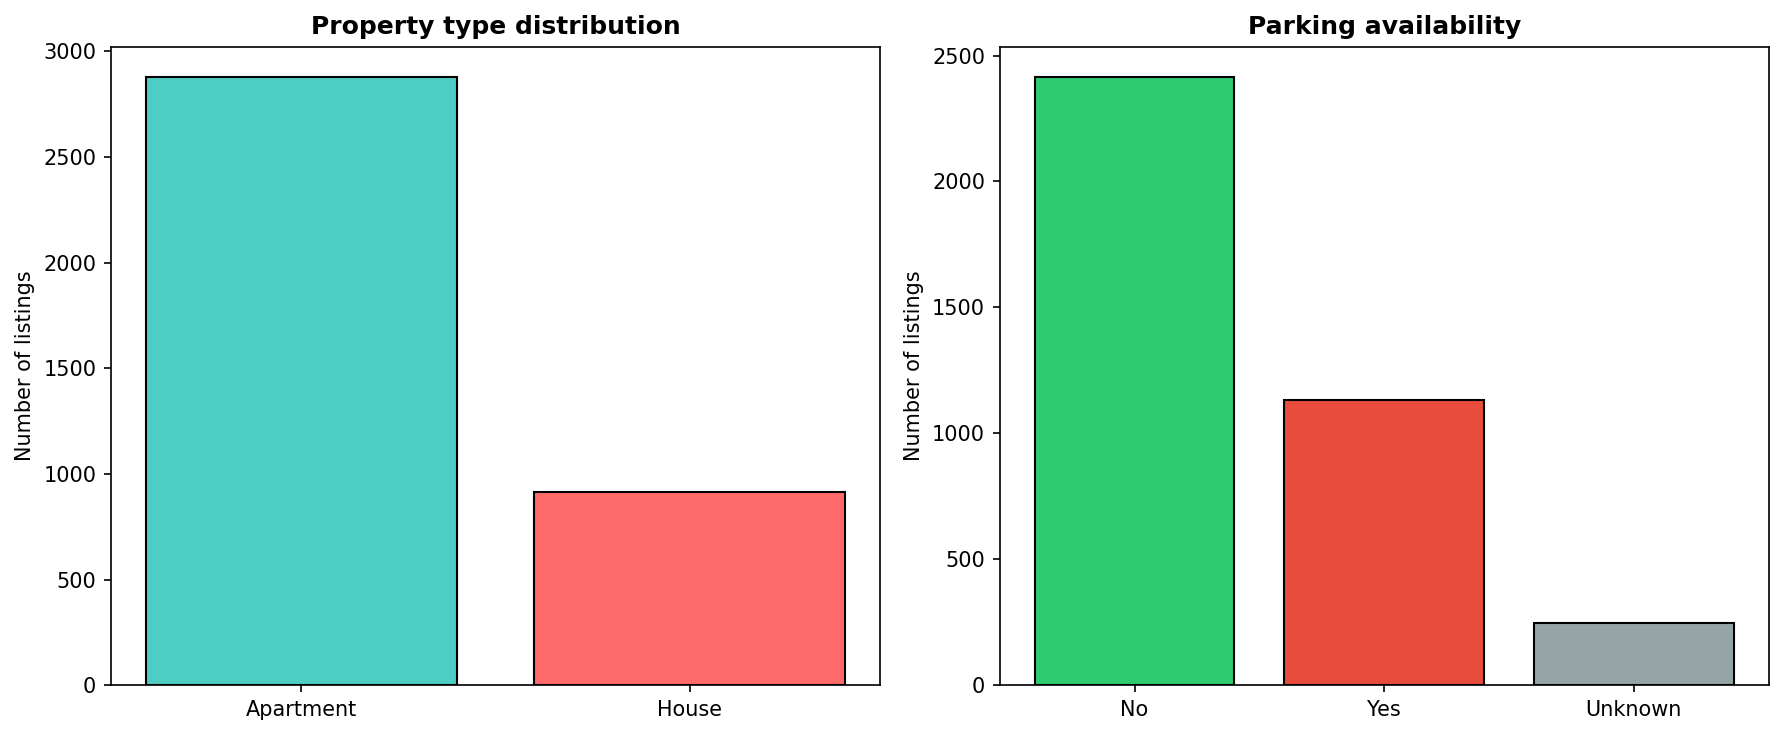

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

type_counts = df['record'].str.extract(r'—\s*(\w+)$')[0].value_counts()
axes[0].bar(type_counts.index, type_counts.values, color=['#4ECDC4','#FF6B6B'], edgecolor='black')
axes[0].set_title('Property type distribution', fontweight='bold')
axes[0].set_ylabel('Number of listings')

park_counts = df['parking_clean'].value_counts(dropna=False)
park_labels = ['Yes' if x == True else ('No' if x == False else 'Unknown') for x in park_counts.index]
axes[1].bar(park_labels, park_counts.values, color=['#2ECC71','#E74C3C','#95A5A6'], edgecolor='black')
axes[1].set_title('Parking availability', fontweight='bold')
axes[1].set_ylabel('Number of listings')

plt.tight_layout()
plt.savefig('output/property_features.png', dpi=150, bbox_inches='tight')
Image('output/property_features.png')

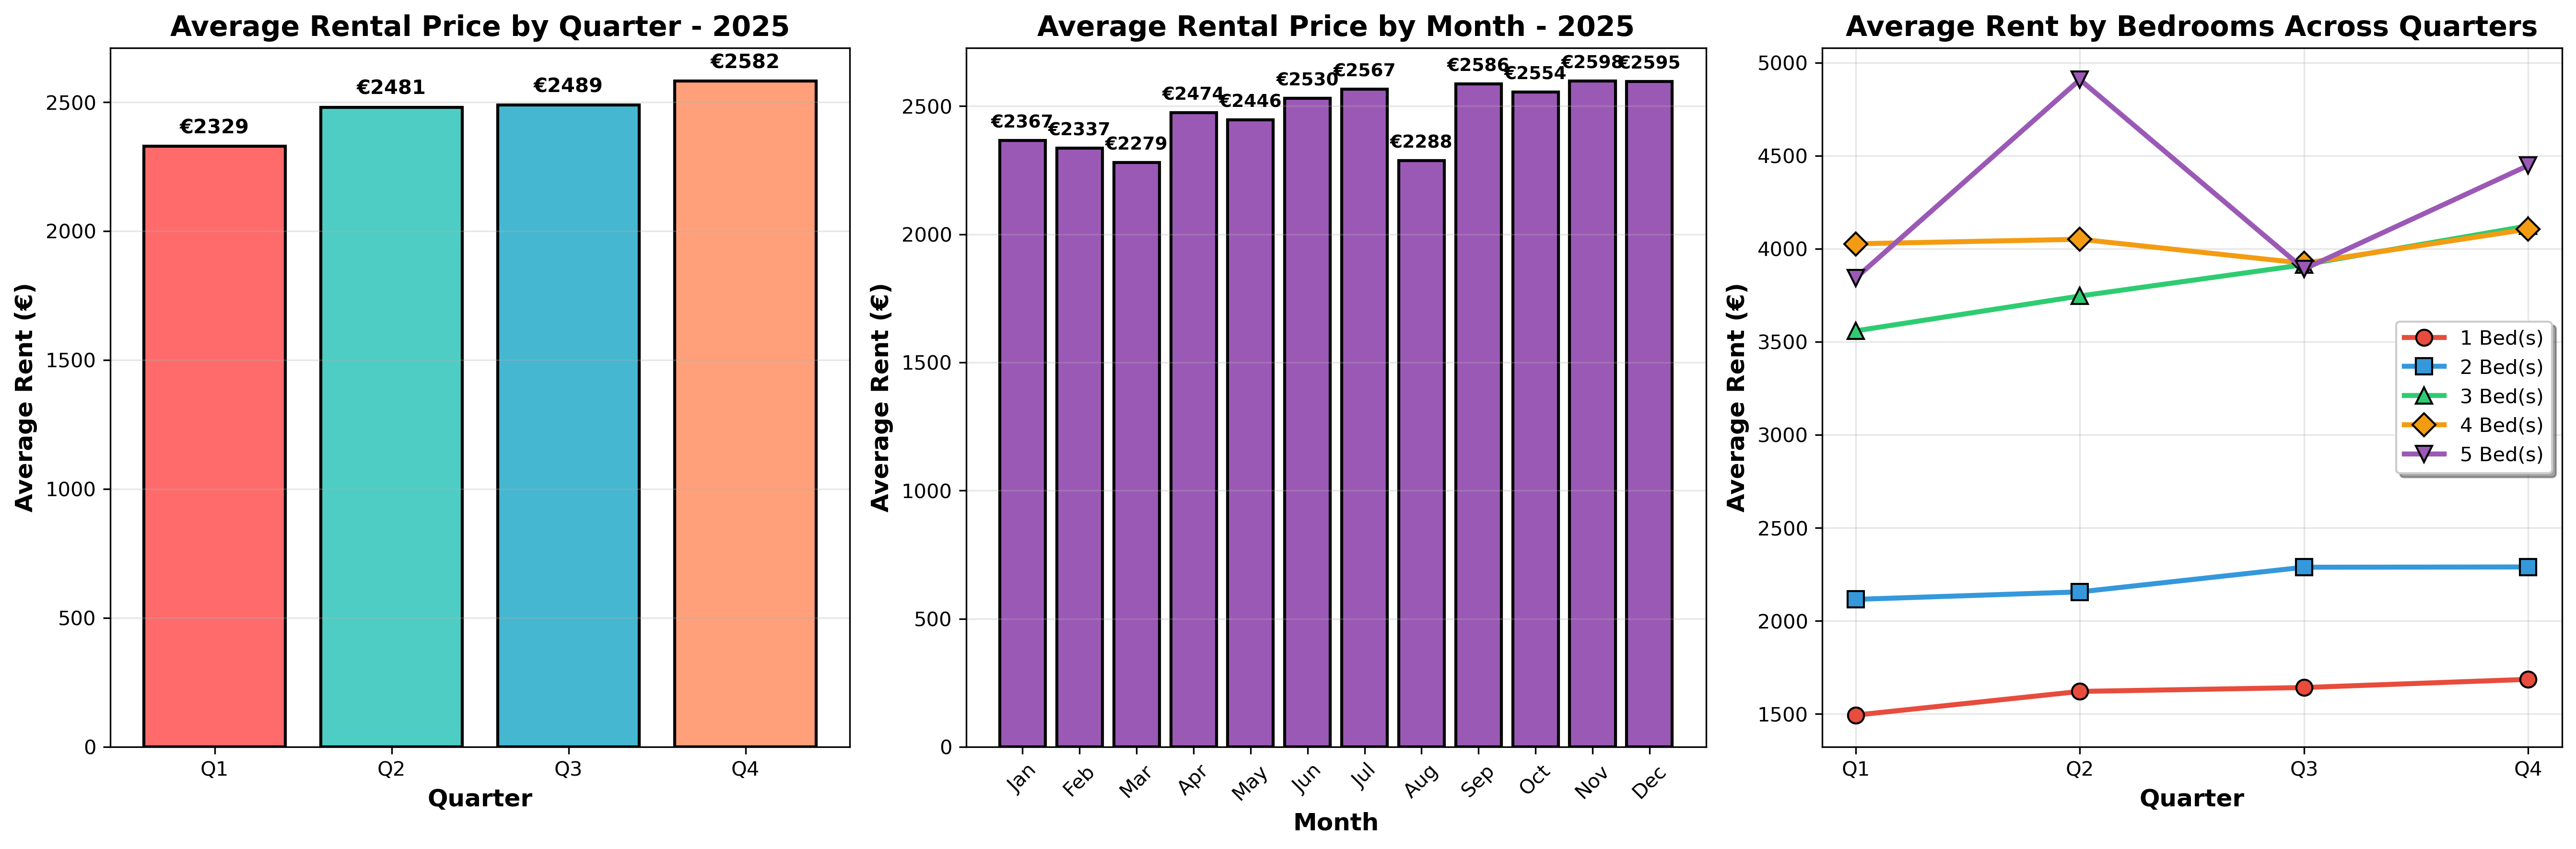

In [37]:
# show graphs saved above
Image('output/rental_analysis_complete.png')

In [39]:
# References

# https://stackoverflow.com/questions/3207219/how-do-i-list-all-files-of-a-directory

# Task3
## Discussion

### a) Challenges in scraping and cleaning the data

**Scraping challenges:**

The webpage held all of it's listings on a pagination system - with quarterly listings on their own pages and then each quarterly's listings in many more pages as per below url

www.mlg.ucd.ie/modules/python/sources/rental/ **Q1** -page **11** .html


This made things a little more difficult because rather than just prompting a single url and pulling down the data and interpreting it - I had to write code that would call multiple pages and also understand when a listing didn't exist and move on to the next page or quarter. This was done by checking for 404 responses and proved to be a neater solution than first envisaged.

To be safe I added safety limits - such as a max 200 HTTP requests, and only allowed the software to check for a maximum of 50 pages per quarter - as each page had roughly 25 listings - I thought it unlikely a quarterly's listings would exceed 1250 and did experience one or two infinite loops while developing the code so I thought this was a useful safety measure.

**Cleaning challenges:**

The Price field was the most problematic, containing loads of different formats across listings — including `€1,230`, `EUR 1,830`, `840.00 per month`, and bare numbers like `2520`. I wrote a custom parsing function was written to strip currency symbols, commas, and the phrase "per month" before converting to a float. Rows that still couldn't be parsed were set to NaN and excluded from analysis, which overall is a weakness in it's analysis but I felt was the most reliable and technically responsible.

The Parking and Garden fields used 9+ different representations of true/false — `Y`, `Yes`, `True`, `1` for positive and `N`, `No`, `False`, `0` for negative. A mapping function standardised these into proper booleans, with blank or ambiguous values such as `"Unknown"` and `"—"` set to NaN as above.

The Bedrooms and Bathrooms columns mixed plain integers with strings like `"3 Bedrooms"` and `"1 Bathroom"`. A regex extraction function was used to pull the numeric value consistently from any format.

---

### b) Key insights from the analysis

Rental prices showed a clear and consistent upward trend throughout 2025(who would have guessed!). Average 1-bedroom rents rose from €1,494 in quarter one to €1,686 in quarter 4 — an increase of roughly 13% over the year. 3 bedroom properties increased more sharply, from €3,559 in quarter one to €4,124 in quarter four.

The relationship between bedroom count and price was strong and consistent across all quarters. 1 bedroom properties averaged around €1,600 per month while 3 bedroom properties averaged around €3,800. This premium was stable across all four quarters, suggesting bedroom count is one of the most reliable predictors of rental price in this dataset.

Apartments made up the clear majority of listings, reflecting the urban Dublin market where apartment style living dominates. The dataset also showed that parking was available in a minority of listings, consistent with the high proportion of city centre apartments where parking is less common.

### c) Ideas for further work

The Location field contains Dublin area names and postcodes (Dublin 4, North Co Dublin, Dublin City South etc.) which could be parsed and used to compare rental prices by area. Location is a big player in this dataset and in hindsight I regret not writing a function to present this data in a maps solution - perhaps lik LeafletJS or something similar.

with a clean dataset like this - in theory a regression model could have been trained to predict rising cost of living, had I had a dataset relating to crime in urban dublin and or income or other socio-economic datasets - this may have well proved an intersting prediction tool for how communities will look from a financial or cost standpoint in years to come.

It would also be interesting to compare these patterns against real data published by the Residential Tenancies Board (RTB) to assess whether this dummy dataset reflects actual trends in the Dublin rental market.

Finally, the Contact field distinguishes between estate agent and owner listings. Testing whether one type consistently commands higher prices than the other could reveal an interesting dynamic in how properties are brought to market, in a real world tool, even collecting data to determine if these properties are on market for longer than their competitors or vitally if they return to market quickly enough - could prove to be a useful tool for 'ranking' estate agents and assessing different socio-economic groups tendencies to move more often or stay put.